# Étape 3 — Trajectoires et options exotiques

Jusqu'ici, le payoff ne dépendait que de $S_T$. Les options exotiques dépendent de **toute la trajectoire** : il faut simuler $S$ sur une grille $0 = t_0 < t_1 < \dots < t_n = T$, avec $t_k = k\,\Delta t$ et $\Delta t = T/n$.

- **Partie A — Schémas de discrétisation** : Euler et Milstein, erreur forte et erreur faible, mesurées contre la solution exacte.
- **Partie B — Options asiatiques** : la moyenne géométrique comme variable de contrôle, et le QMC en dimension $n$ avec le pont brownien.
- **Partie C — Options barrières** : le biais de surveillance discrète, la correction de Broadie-Glasserman-Kou et la correction par pont brownien.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, qmc
from scipy.stats import t as student

## 0. Briques de base

In [2]:
def summarize(samples, alpha=0.05):
    """Prix, erreur standard et IC (quantile de Student, ≈ 1,96 pour un grand échantillon)."""
    samples = np.asarray(samples)
    n = len(samples)
    price = samples.mean()
    se = samples.std(ddof=1) / np.sqrt(n)
    q = student.ppf(1 - alpha / 2, df=n - 1)
    return price, se, (price - q * se, price + q * se)


def bs_call_price(S0, K, T, r, sigma):
    d1 = (np.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)


def paths_from_normals(S0, T, r, sigma, Z):
    """
    Trajectoires EXACTES de Black-Scholes aux dates t_1, ..., t_n à partir de gaussiennes Z (N x n).
    On enchaîne la formule de l'étape 1 sur chaque pas : log S_{k+1} = log S_k + (r - σ²/2)Δt + σ√Δt Z_k.
    Renvoie un tableau N x n : colonne k = S_{t_{k+1}}.
    """
    n_steps = Z.shape[1]
    dt = T / n_steps
    log_increments = (r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z
    return S0 * np.exp(np.cumsum(log_increments, axis=1))


params = dict(S0=100.0, K=100.0, T=1.0, r=0.03, sigma=0.2)
S0, K, T, r, sigma = params.values()
disc = np.exp(-r * T)

# Partie A — Schémas de discrétisation

Pour un modèle général $dS_t = a(S_t)\,dt + b(S_t)\,dW_t$ sans solution explicite (comme Heston à l'étape 5), on approche la trajectoire pas à pas, avec $\Delta W_k = \sqrt{\Delta t}\,Z_k$ :

**Euler :** $\quad \hat S_{k+1} = \hat S_k + a(\hat S_k)\,\Delta t + b(\hat S_k)\,\Delta W_k$

**Milstein :** $\quad \hat S_{k+1} = \hat S_k + a(\hat S_k)\,\Delta t + b(\hat S_k)\,\Delta W_k + \tfrac12\, b(\hat S_k)\, b'(\hat S_k)\big(\Delta W_k^2 - \Delta t\big)$

Pour Black-Scholes, $a(s) = rs$ et $b(s) = \sigma s$, donc $b\,b' = \sigma^2 s$ :

$$\text{Euler : } \hat S_{k+1} = \hat S_k\big(1 + r\Delta t + \sigma\Delta W_k\big) \qquad \text{Milstein : } \hat S_{k+1} = \hat S_k\big(1 + r\Delta t + \sigma\Delta W_k + \tfrac12\sigma^2(\Delta W_k^2 - \Delta t)\big)$$

On les teste sur Black-Scholes **parce qu'on connaît la solution exacte**, simulée avec les **mêmes** $\Delta W_k$.

Deux notions d'erreur :
- **erreur forte** $\;\mathbb E\big[|\hat S_T - S_T|\big]$ : la trajectoire simulée est-elle proche de la vraie, tirage par tirage ? Euler : ordre $\frac12$, Milstein : ordre $1$ ;
- **erreur faible** $\;\big|\mathbb E[f(\hat S_T)] - \mathbb E[f(S_T)]\big|$ : la **loi** est-elle bonne ? C'est elle qui compte pour le pricing. Euler et Milstein : ordre $1$.

In [3]:
def terminal_values_schemes(S0, T, r, sigma, n_paths, n_steps, seed=None):
    """S_T exact, Euler et Milstein, construits avec les MÊMES accroissements browniens."""
    rng = np.random.default_rng(seed)
    dt = T / n_steps
    S_exact = np.full(n_paths, S0)
    S_euler = np.full(n_paths, S0)
    S_milstein = np.full(n_paths, S0)
    for _ in range(n_steps):                       # boucle sur le temps : mémoire O(N) seulement
        dW = np.sqrt(dt) * rng.standard_normal(n_paths)
        S_exact = S_exact * np.exp((r - 0.5 * sigma**2) * dt + sigma * dW)
        S_euler = S_euler * (1 + r * dt + sigma * dW)
        S_milstein = S_milstein * (1 + r * dt + sigma * dW + 0.5 * sigma**2 * (dW**2 - dt))
    return S_exact, S_euler, S_milstein

## A.1 Erreur forte

Même graine pour toutes les tailles de pas ; on mesure $\mathbb E\big[|\hat S_T - S_T|\big]$ pour Euler et Milstein.

    n        Δt      Euler   Milstein
    2   0.50000    1.50781   0.217968
    4   0.25000    1.10836   0.120308
    8   0.12500    0.80107   0.064374
   16   0.06250    0.57331   0.033588
   32   0.03125    0.40942   0.017239
   64   0.01562    0.28972   0.008684
  128   0.00781    0.20487   0.004365
  256   0.00391    0.14490   0.002185


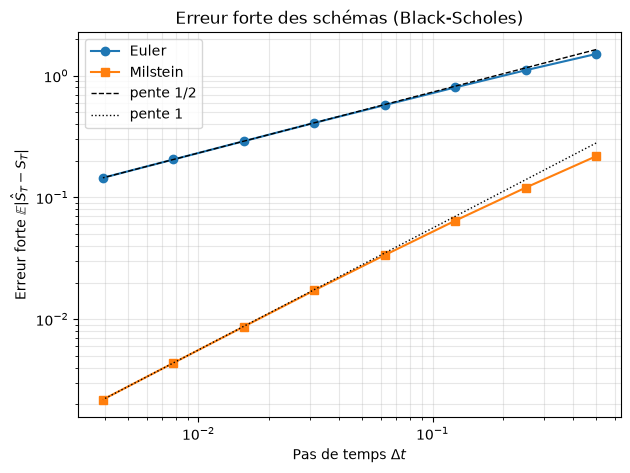

In [4]:
steps_list = [2, 4, 8, 16, 32, 64, 128, 256]
strong_euler, strong_milstein = [], []
for n in steps_list:
    S_ex, S_eu, S_mi = terminal_values_schemes(S0, T, r, sigma, n_paths=100_000, n_steps=n, seed=1)
    strong_euler.append(np.mean(np.abs(S_eu - S_ex)))
    strong_milstein.append(np.mean(np.abs(S_mi - S_ex)))

print(f"{'n':>5} {'Δt':>9} {'Euler':>10} {'Milstein':>10}")
for n, e, m in zip(steps_list, strong_euler, strong_milstein):
    print(f"{n:>5} {T/n:>9.5f} {e:>10.5f} {m:>10.6f}")

dts = T / np.array(steps_list)
plt.figure(figsize=(7, 5))
plt.loglog(dts, strong_euler, "o-", label="Euler")
plt.loglog(dts, strong_milstein, "s-", label="Milstein")
plt.loglog(dts, strong_euler[-1] * np.sqrt(dts / dts[-1]), "k--", lw=1, label=r"pente $1/2$")
plt.loglog(dts, strong_milstein[-1] * (dts / dts[-1]), "k:", lw=1, label=r"pente $1$")
plt.xlabel(r"Pas de temps $\Delta t$")
plt.ylabel(r"Erreur forte $\mathbb{E}|\hat S_T - S_T|$")
plt.title("Erreur forte des schémas (Black-Scholes)")
plt.legend(); plt.grid(True, which="both", alpha=0.3)
plt.show()

## A.2 Erreur faible : un calcul exact sur $\mathbb E[S_T^2]$

Pour Black-Scholes, on peut calculer **exactement** le second moment, sans aucun bruit Monte Carlo. En utilisant $\mathbb E[\Delta W_k] = 0$, $\mathbb E[\Delta W_k^2] = \Delta t$, $\mathbb E[\Delta W_k^3] = 0$ et $\mathbb E\big[(\Delta W_k^2 - \Delta t)^2\big] = 2\Delta t^2$, et l'indépendance des pas :

$$\mathbb E[S_T^2] = S_0^2\,e^{(2r + \sigma^2)T}, \qquad
\mathbb E[\hat S_T^{2,\text{Euler}}] = S_0^2\Big((1 + r\Delta t)^2 + \sigma^2\Delta t\Big)^n, \qquad
\mathbb E[\hat S_T^{2,\text{Milstein}}] = S_0^2\Big((1 + r\Delta t)^2 + \sigma^2\Delta t + \tfrac12\sigma^4\Delta t^2\Big)^n$$

L'erreur faible des deux schémas est d'ordre $1$ en $\Delta t$.

    n   Erreur Euler  Erreur Milstein
    2      -21.98367        -17.78237
    4      -11.15707         -9.00278
    8       -5.62090         -4.52990
   16       -2.82118         -2.27216
   32       -1.41329         -1.13789
   64       -0.70732         -0.56940
  128       -0.35383         -0.28481
  256       -0.17696         -0.14243


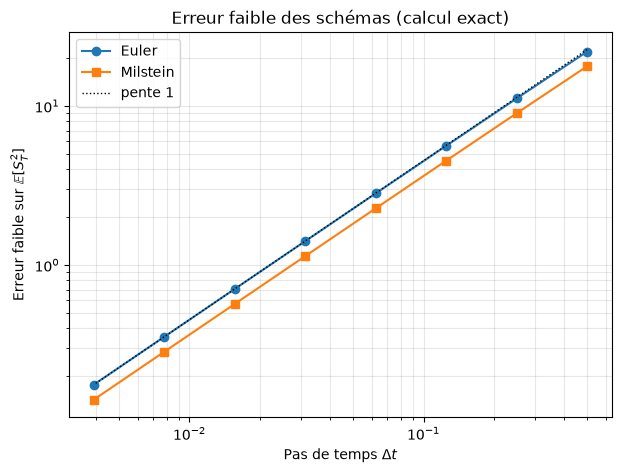

In [5]:
exact_m2 = S0**2 * np.exp((2 * r + sigma**2) * T)
weak_euler_m2, weak_milstein_m2 = [], []
print(f"{'n':>5} {'Erreur Euler':>14} {'Erreur Milstein':>16}")
for n in steps_list:
    dt = T / n
    e = S0**2 * ((1 + r * dt)**2 + sigma**2 * dt)**n - exact_m2
    m = S0**2 * ((1 + r * dt)**2 + sigma**2 * dt + 0.5 * sigma**4 * dt**2)**n - exact_m2
    weak_euler_m2.append(abs(e)); weak_milstein_m2.append(abs(m))
    print(f"{n:>5} {e:>14.5f} {m:>16.5f}")

plt.figure(figsize=(7, 5))
plt.loglog(dts, weak_euler_m2, "o-", label="Euler")
plt.loglog(dts, weak_milstein_m2, "s-", label="Milstein")
plt.loglog(dts, weak_euler_m2[-1] * (dts / dts[-1]), "k:", lw=1, label=r"pente $1$")
plt.xlabel(r"Pas de temps $\Delta t$")
plt.ylabel(r"Erreur faible sur $\mathbb{E}[S_T^2]$")
plt.title("Erreur faible des schémas (calcul exact)")
plt.legend(); plt.grid(True, which="both", alpha=0.3)
plt.show()

## A.3 Erreur faible sur le prix du call

Le biais $\mathbb E[\hat Y] - \mathbb E[Y]$ est petit devant le bruit Monte Carlo. Pour le mesurer, on estime **la différence** $\hat Y - Y$ tirage par tirage, avec les mêmes accroissements (*nombres aléatoires communs*) : sa variance est bien plus faible que celle de chaque prix.

Pour le call, le biais d'Euler se trouve être presque nul (des effets de signes opposés se compensent) : il est noyé dans le bruit. Celui de Milstein décroît bien en $\Delta t$.

In [6]:
print(f"{'n':>5} {'Biais Euler':>12} {'± SE':>9} {'Biais Milstein':>15} {'± SE':>9}")
for n in steps_list[:-1]:
    S_ex, S_eu, S_mi = terminal_values_schemes(S0, T, r, sigma, n_paths=200_000, n_steps=n, seed=2)
    Y_ex = disc * np.maximum(S_ex - K, 0)
    be, se_e, _ = summarize(disc * np.maximum(S_eu - K, 0) - Y_ex)
    bm, se_m, _ = summarize(disc * np.maximum(S_mi - K, 0) - Y_ex)
    print(f"{n:>5} {be:>+12.5f} {se_e:>9.5f} {bm:>+15.5f} {se_m:>9.5f}")

    n  Biais Euler      ± SE  Biais Milstein      ± SE
    2     -0.03150   0.00369        -0.11692   0.00058
    4     -0.00538   0.00258        -0.06141   0.00029
    8     -0.00058   0.00185        -0.03155   0.00015
   16     -0.00010   0.00132        -0.01608   0.00008
   32     -0.00047   0.00094        -0.00810   0.00004
   64     -0.00006   0.00066        -0.00405   0.00002
  128     +0.00024   0.00047        -0.00204   0.00001


**À retenir :** pour le pricing, c'est l'erreur **faible** qui compte. Elle produit un **biais** en $O(\Delta t)$, qui s'ajoute à l'erreur statistique en $O(1/\sqrt N)$. Pour un budget de calcul fixé, il faut équilibrer les deux : inutile de prendre $N$ énorme si $\Delta t$ est grossier, et inversement. Sous Black-Scholes, on simulera désormais les trajectoires **exactement** (`paths_from_normals`) : le biais de discrétisation disparaît.

# Partie B — Options asiatiques

Payoff sur la moyenne **arithmétique** des prix aux dates $t_1, \dots, t_n$ :

$$Y = e^{-rT}\big(A_n - K\big)^+, \qquad A_n = \frac1n\sum_{k=1}^n S_{t_k}$$

$A_n$ est une somme de log-normales : **pas de formule fermée**. En revanche, la moyenne **géométrique** $G_n = \big(\prod_k S_{t_k}\big)^{1/n}$ est log-normale :

$$\ln G_n \sim \mathcal N\big(\mu_G, \sigma_G^2\big), \qquad \mu_G = \ln S_0 + \Big(r - \frac{\sigma^2}{2}\Big)\frac{T(n+1)}{2n}, \qquad \sigma_G^2 = \sigma^2\,\frac{T(n+1)(2n+1)}{6n^2}$$

d'où une formule fermée à la Black-Scholes, avec $d_2 = \frac{\mu_G - \ln K}{\sigma_G}$ et $d_1 = d_2 + \sigma_G$ :

$$C_G = e^{-rT}\Big(e^{\mu_G + \sigma_G^2/2}\,\Phi(d_1) - K\,\Phi(d_2)\Big)$$

Comme $G_n \le A_n$ et que les deux moyennes sont très proches, le payoff géométrique $X = e^{-rT}(G_n - K)^+$ est une **variable de contrôle** quasi parfaite, d'espérance connue $C_G$.

In [7]:
def geometric_asian_call(S0, K, T, r, sigma, n):
    """Formule fermée de l'asiatique géométrique (moyenne sur t_1, ..., t_n)."""
    mu = np.log(S0) + (r - 0.5 * sigma**2) * T * (n + 1) / (2 * n)
    s = sigma * np.sqrt(T * (n + 1) * (2 * n + 1) / (6 * n**2))
    d2 = (mu - np.log(K)) / s
    d1 = d2 + s
    return np.exp(-r * T) * (np.exp(mu + 0.5 * s**2) * norm.cdf(d1) - K * norm.cdf(d2))


def asian_payoffs(S):
    """Payoffs actualisés arithmétique (Y) et géométrique (X) à partir des trajectoires S (N x n)."""
    A = S.mean(axis=1)
    G = np.exp(np.log(S).mean(axis=1))
    return disc * np.maximum(A - K, 0.0), disc * np.maximum(G - K, 0.0)

## B.1 Validation de la formule géométrique, puis variable de contrôle

   n  Géo exact    Géo MC  IC ok |  Arith. std       SE |  Arith. CV        SE        ρ     b*  Réd. var.
  12     5.4353    5.4671   True |      5.6646   0.0261 |     5.6318   0.00071  0.99963  1.031       1338
  52     5.1669    5.1304   True |      5.3266   0.0246 |     5.3643   0.00067  0.99964  1.034       1371


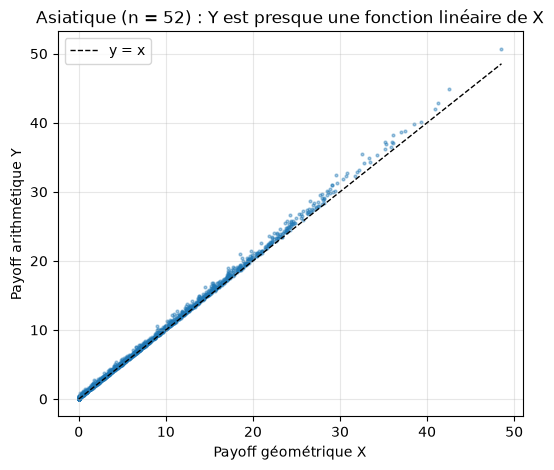

In [8]:
print(f"{'n':>4} {'Géo exact':>10} {'Géo MC':>9} {'IC ok':>6} | {'Arith. std':>11} {'SE':>8} | {'Arith. CV':>10} {'SE':>9} {'ρ':>8} {'b*':>6} {'Réd. var.':>10}")
cv_example = None
for n in [12, 52]:
    rng = np.random.default_rng(10 + n)
    S = paths_from_normals(S0, T, r, sigma, rng.standard_normal((100_000, n)))
    Y, X = asian_payoffs(S)
    CG = geometric_asian_call(S0, K, T, r, sigma, n)

    g_mc, g_se, (g_lo, g_hi) = summarize(X)
    p_std, se_std, _ = summarize(Y)

    cov = np.cov(Y, X)
    b = cov[0, 1] / cov[1, 1]
    rho = cov[0, 1] / np.sqrt(cov[0, 0] * cov[1, 1])
    p_cv, se_cv, _ = summarize(Y - b * (X - CG))
    print(f"{n:>4} {CG:>10.4f} {g_mc:>9.4f} {str(g_lo <= CG <= g_hi):>6} | {p_std:>11.4f} {se_std:>8.4f} | "
          f"{p_cv:>10.4f} {se_cv:>9.5f} {rho:>8.5f} {b:>6.3f} {(se_std / se_cv)**2:>10.0f}")
    if n == 52:
        cv_example = (X[:3000], Y[:3000])

Xs, Ys = cv_example
plt.figure(figsize=(6, 5))
plt.scatter(Xs, Ys, s=4, alpha=0.4)
plt.plot([0, Xs.max()], [0, Xs.max()], "k--", lw=1, label="y = x")
plt.xlabel("Payoff géométrique X"); plt.ylabel("Payoff arithmétique Y")
plt.title("Asiatique (n = 52) : Y est presque une fonction linéaire de X")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

Avec $\rho \approx 0{,}9996$, la variable de contrôle divise la variance par plus de **1 000** : bien mieux qu'avec $S_T$ pour le call européen. C'est le cas d'école de la méthode.

## B.2 Le QMC en dimension $n$ : construction incrémentale ou pont brownien ?

Une trajectoire à $n$ dates demande $n$ gaussiennes : le QMC travaille désormais en **dimension $n$**. Or les premières coordonnées d'une suite de Sobol sont bien mieux réparties que les dernières.

- **Construction incrémentale** : la coordonnée $k$ donne l'accroissement $W_{t_k} - W_{t_{k-1}}$. Toutes les coordonnées ont le même poids.
- **Pont brownien** : la 1re coordonnée fixe $W_T$, la 2e $W_{T/2}$ sachant $W_0$ et $W_T$, puis $W_{T/4}$ et $W_{3T/4}$, etc. Les mouvements **de grande échelle**, qui pèsent le plus sur la moyenne, sont portés par les premières coordonnées, les mieux réparties : la **dimension effective** baisse.

Loi du pont brownien : sachant $W_s = a$ et $W_u = b$, pour $s < t < u$,

$$W_t \;\Big|\; (W_s = a,\, W_u = b) \;\sim\; \mathcal N\!\left(\frac{(u-t)\,a + (t-s)\,b}{u-s}\ ,\ \frac{(t-s)(u-t)}{u-s}\right)$$

Les deux constructions donnent **exactement la même loi** de trajectoires : seul l'ordre d'utilisation des gaussiennes change. En Monte Carlo classique, c'est donc indifférent ; en QMC, ça change tout.

In [9]:
def brownian_bridge(Z, T):
    """
    Construit W aux dates t_1, ..., t_n (n puissance de 2) par pont brownien.
    Z[:, 0] fixe W_T, Z[:, 1] fixe W_{T/2}, puis W_{T/4} et W_{3T/4}, etc.
    """
    N, n = Z.shape
    assert n & (n - 1) == 0, "n doit être une puissance de 2"
    W = np.zeros((N, n + 1))                       # W[:, k] = W_{t_k}, avec W_{t_0} = 0
    W[:, n] = np.sqrt(T) * Z[:, 0]
    j, h = 1, n
    while h > 1:
        half = h // 2
        for left in range(0, n, h):
            mid, right = left + half, left + h
            t_l, t_m, t_r = left * T / n, mid * T / n, right * T / n
            mean = ((t_r - t_m) * W[:, left] + (t_m - t_l) * W[:, right]) / (t_r - t_l)
            var = (t_m - t_l) * (t_r - t_m) / (t_r - t_l)
            W[:, mid] = mean + np.sqrt(var) * Z[:, j]
            j += 1
        h = half
    return W[:, 1:]


def paths_from_W(S0, T, r, sigma, W):
    """S_{t_k} = S0 exp((r - σ²/2) t_k + σ W_{t_k})."""
    n = W.shape[1]
    t_grid = np.arange(1, n + 1) * T / n
    return S0 * np.exp((r - 0.5 * sigma**2) * t_grid + sigma * W)


# Vérification : le pont brownien redonne bien la loi du mouvement brownien
W_check = brownian_bridge(np.random.default_rng(0).standard_normal((200_000, 16)), T)
print(f"Var(W_(T/4)) = {W_check[:, 3].var():.4f}  (théorie : {T/4:.4f})")
print(f"Corr(W_(T/2), W_T) = {np.corrcoef(W_check[:, 7], W_check[:, -1])[0, 1]:.4f}  (théorie : {np.sqrt(0.5):.4f})")

Var(W_(T/4)) = 0.2507  (théorie : 0.2500)
Corr(W_(T/2), W_T) = 0.7081  (théorie : 0.7071)


In [10]:
def rqmc_asian(n, m, n_replications, use_bridge, seed=None):
    """QMC randomisé (Sobol + décalage aléatoire) pour l'asiatique arithmétique, en dimension n."""
    rng = np.random.default_rng(seed)
    sobol = qmc.Sobol(d=n, scramble=False).random_base2(m)       # 2^m points en dimension n
    estimates = np.empty(n_replications)
    for j in range(n_replications):
        u = (sobol + rng.uniform(size=n)) % 1.0                  # un décalage par coordonnée
        Z = norm.ppf(u)
        if use_bridge:
            S = paths_from_W(S0, T, r, sigma, brownian_bridge(Z, T))
        else:
            S = paths_from_normals(S0, T, r, sigma, Z)
        estimates[j] = asian_payoffs(S)[0].mean()
    return summarize(estimates)


R, m = 16, 12                     # budget : 16 x 2^12 = 65 536 trajectoires
budget = R * 2**m
print(f"Budget : {budget} trajectoires par méthode\n")
print(f"{'n':>4} {'MC std (SE)':>12} {'QMC incr. (SE)':>15} {'Réd. var.':>10} {'QMC pont (SE)':>14} {'Réd. var.':>10}")
for n in [4, 16, 64]:
    rng = np.random.default_rng(100 + n)
    _, se_std, _ = summarize(asian_payoffs(paths_from_normals(S0, T, r, sigma, rng.standard_normal((budget, n))))[0])
    _, se_inc, _ = rqmc_asian(n, m, R, use_bridge=False, seed=200 + n)
    _, se_bb, _ = rqmc_asian(n, m, R, use_bridge=True, seed=300 + n)
    print(f"{n:>4} {se_std:>12.5f} {se_inc:>15.5f} {(se_std / se_inc)**2:>10.1f} {se_bb:>14.5f} {(se_std / se_bb)**2:>10.1f}")

Budget : 65536 trajectoires par méthode

   n  MC std (SE)  QMC incr. (SE)  Réd. var.  QMC pont (SE)  Réd. var.
   4      0.03616         0.00379       91.1        0.00256      199.9
  16      0.03157         0.00490       41.5        0.00234      182.3
  64      0.03044         0.00999        9.3        0.00279      119.0


**À retenir :** en dimension 1 (étape 2), le QMC divisait la variance par plus de 1 000. Avec la construction incrémentale, le gain **s'effondre** quand $n$ augmente : c'est la malédiction de la dimension. Le pont brownien en récupère l'essentiel, parce que la dimension **effective** du problème reste faible.

# Partie C — Options barrières

Call **up-and-out** : il paie $(S_T - K)^+$ seulement si le sous-jacent n'a **jamais** touché la barrière $B > S_0$ :

$$Y = e^{-rT}(S_T - K)^+\,\mathbf 1_{\{\max_{0\le t\le T} S_t < B\}}$$

Pour une surveillance **continue**, il existe une formule fermée (Reiner-Rubinstein), avec $\lambda = \frac{r + \sigma^2/2}{\sigma^2}$ :

$$C_{uo} = C_{BS} - C_{ui}, \qquad C_{ui} = S_0\Phi(x_1) - Ke^{-rT}\Phi(x_1 - \sigma\sqrt T) - S_0\Big(\tfrac{B}{S_0}\Big)^{2\lambda}\big[\Phi(-y) - \Phi(-y_1)\big] + Ke^{-rT}\Big(\tfrac{B}{S_0}\Big)^{2\lambda - 2}\big[\Phi(-y + \sigma\sqrt T) - \Phi(-y_1 + \sigma\sqrt T)\big]$$

$$x_1 = \frac{\ln(S_0/B)}{\sigma\sqrt T} + \lambda\sigma\sqrt T, \qquad y = \frac{\ln\big(B^2/(S_0K)\big)}{\sigma\sqrt T} + \lambda\sigma\sqrt T, \qquad y_1 = \frac{\ln(B/S_0)}{\sigma\sqrt T} + \lambda\sigma\sqrt T$$

**Le problème :** une simulation ne regarde $S$ qu'aux dates $t_k$. Elle **rate les franchissements entre deux dates** : elle garde vivantes des trajectoires qui auraient dû être désactivées, et **surestime** le prix.

In [11]:
def up_and_out_call(S0, K, T, r, sigma, B):
    """Formule fermée du call up-and-out, surveillance continue, B > K."""
    st = sigma * np.sqrt(T)
    lam = (r + 0.5 * sigma**2) / sigma**2
    x1 = np.log(S0 / B) / st + lam * st
    y = np.log(B**2 / (S0 * K)) / st + lam * st
    y1 = np.log(B / S0) / st + lam * st
    c_ui = (S0 * norm.cdf(x1) - K * np.exp(-r * T) * norm.cdf(x1 - st)
            - S0 * (B / S0)**(2 * lam) * (norm.cdf(-y) - norm.cdf(-y1))
            + K * np.exp(-r * T) * (B / S0)**(2 * lam - 2) * (norm.cdf(-y + st) - norm.cdf(-y1 + st)))
    return bs_call_price(S0, K, T, r, sigma) - c_ui


B = 130.0
exact_barrier = up_and_out_call(S0, K, T, r, sigma, B)
print(f"Call up-and-out (K = {K:.0f}, B = {B:.0f}), surveillance continue : {exact_barrier:.4f}")
print(f"Pour comparaison, call européen : {bs_call_price(S0, K, T, r, sigma):.4f}")

Call up-and-out (K = 100, B = 130), surveillance continue : 3.2027
Pour comparaison, call européen : 9.4134


## C.1 Les trois estimateurs

**1. Naïf :** la trajectoire est désactivée si un $S_{t_k} \ge B$. Biais vers le haut.

**2. Broadie-Glasserman-Kou (BGK) :** un résultat asymptotique dit qu'une barrière surveillée à pas $\Delta t$ se comporte comme une barrière continue déplacée de $e^{\beta\sigma\sqrt{\Delta t}}$, avec $\beta = -\zeta(1/2)/\sqrt{2\pi} \approx 0{,}5826$. Pour approcher le prix **continu** avec une simulation discrète, on **abaisse** donc la barrière : $B' = B\,e^{-\beta\sigma\sqrt{\Delta t}}$. Le biais résiduel est en $o(\sqrt{\Delta t})$.

**3. Pont brownien :** entre deux dates, le log-prix $x_t = \ln S_t$ est un mouvement brownien avec dérive. Sachant $x_{t_k}$ et $x_{t_{k+1}}$, tous deux sous $b = \ln B$, la probabilité d'avoir franchi la barrière **entre** les deux dates est connue exactement :

$$p_k = \exp\!\left(-\frac{2\,(b - x_{t_k})(b - x_{t_{k+1}})}{\sigma^2\,\Delta t}\right)$$

Au lieu de tirer au hasard si la barrière a été touchée, on **pondère** le payoff par la probabilité de survie :

$$Y = e^{-rT}(S_T - K)^+\,\prod_{k=0}^{n-1}\big(1 - p_k\big)\,\mathbf 1_{\{x_{t_{k+1}} < b\}}$$

Sous Black-Scholes, cet estimateur est **exactement sans biais** pour la barrière continue, quel que soit $\Delta t$.

In [12]:
def barrier_mc(S0, K, T, r, sigma, B, n_steps, n_paths, method="naive", seed=None):
    """
    Call up-and-out par Monte Carlo, trajectoires exactes aux dates t_k.
    method : "naive", "bgk" (barrière déplacée) ou "bridge" (probabilité de franchissement).
    """
    rng = np.random.default_rng(seed)
    dt = T / n_steps
    B_sim = B * np.exp(-0.5826 * sigma * np.sqrt(dt)) if method == "bgk" else B
    b = np.log(B_sim)

    x = np.full(n_paths, np.log(S0))               # log-prix
    alive = np.ones(n_paths, dtype=bool)
    weight = np.ones(n_paths)
    for _ in range(n_steps):
        x_next = x + (r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * rng.standard_normal(n_paths)
        alive &= (x_next < b)                       # franchissement observé à une date de la grille
        if method == "bridge":                      # franchissement entre deux dates
            p_cross = np.exp(-2 * np.maximum(b - x, 0) * np.maximum(b - x_next, 0) / (sigma**2 * dt))
            weight *= 1 - p_cross
        x = x_next

    payoffs = disc * np.maximum(np.exp(x) - K, 0.0) * alive * weight
    return summarize(payoffs)

## C.2 Comparaison selon le nombre de dates de surveillance

Prix exact (continu) : 3.2027

    n                    Naïf                     BGK           Pont brownien
    4      4.5267 ± 0.0167  ✗      2.8170 ± 0.0121  ✗      3.2052 ± 0.0119  ✓
   12      4.0692 ± 0.0157  ✗      3.0775 ± 0.0130  ✗      3.2099 ± 0.0126  ✓
   52      3.6301 ± 0.0147  ✗      3.1577 ± 0.0134  ✗      3.1851 ± 0.0130  ✓
  252      3.4178 ± 0.0141  ✗      3.2106 ± 0.0136  ✓      3.2134 ± 0.0134  ✓


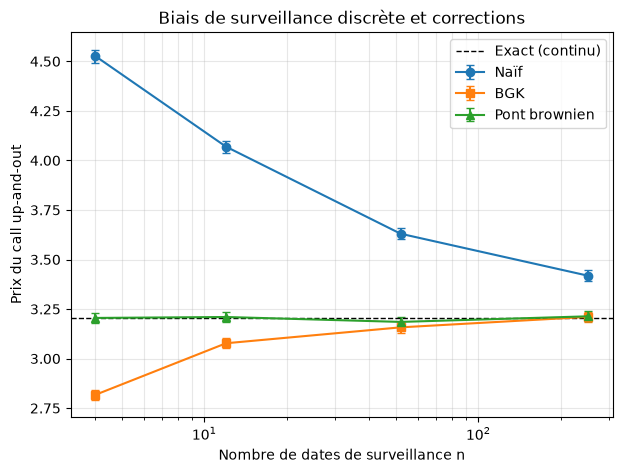

In [13]:
steps_barrier = [4, 12, 52, 252]
results = {m: [] for m in ["naive", "bgk", "bridge"]}
labels = {"naive": "Naïf", "bgk": "BGK", "bridge": "Pont brownien"}

print(f"Prix exact (continu) : {exact_barrier:.4f}\n")
print(f"{'n':>5}" + "".join(f"{labels[m]:>24}" for m in results))
for n in steps_barrier:
    row = f"{n:>5}"
    for meth in results:
        p, se, (lo, hi) = barrier_mc(S0, K, T, r, sigma, B, n, 200_000, meth, seed=7)
        results[meth].append((p, se))
        row += f"{p:>12.4f} ± {se:.4f}{'  ✓' if lo <= exact_barrier <= hi else '  ✗'}"
    print(row)

plt.figure(figsize=(7, 5))
for meth, marker in zip(results, ["o", "s", "^"]):
    p = np.array([v[0] for v in results[meth]])
    se = np.array([v[1] for v in results[meth]])
    plt.errorbar(steps_barrier, p, yerr=1.96 * se, fmt=marker + "-", capsize=3, label=labels[meth])
plt.axhline(exact_barrier, color="k", ls="--", lw=1, label="Exact (continu)")
plt.xscale("log")
plt.xlabel("Nombre de dates de surveillance n")
plt.ylabel("Prix du call up-and-out")
plt.title("Biais de surveillance discrète et corrections")
plt.legend(); plt.grid(True, which="both", alpha=0.3)
plt.show()

**À retenir :**
- l'estimateur **naïf** surestime fortement le prix, et son biais décroît seulement en $\sqrt{\Delta t}$ : même avec 252 dates, il reste visible ;
- la correction **BGK** est très bonne dès que $n$ est assez grand, mais c'est un résultat asymptotique : elle se trompe avec très peu de dates ;
- le **pont brownien** est sans biais pour tout $n$ : 4 dates suffisent. C'est la méthode de référence quand on connaît la loi du pont, ce qui est le cas sous Black-Scholes.

Attention à ne pas confondre : si le contrat surveille vraiment la barrière à des dates discrètes (par exemple chaque clôture), c'est le prix **discret** qu'on veut, et l'estimateur naïf avec les vraies dates est alors le bon.

# Bilan de l'étape 3

| Sujet | Résultat clé |
|---|---|
| Schémas | Erreur forte : Euler $\tfrac12$, Milstein $1$. Erreur faible : ordre $1$ pour les deux. Le pricing dépend de l'erreur faible. |
| Biais vs variance | Erreur totale = biais de discrétisation $O(\Delta t)$ + erreur statistique $O(1/\sqrt N)$ : les deux s'équilibrent. |
| Asiatique | La moyenne géométrique comme contrôle : $\rho \approx 0{,}9996$, variance divisée par plus de 1 000. |
| QMC en dimension $n$ | Le gain s'effondre avec la construction incrémentale ; le pont brownien le récupère. |
| Barrière | Biais de surveillance en $\sqrt{\Delta t}$ ; BGK le corrige asymptotiquement ; le pont brownien le supprime exactement. |